In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from openpyxl import load_workbook
from numba import jit
import math

In [31]:
# Define the boundary and well radius
l = 4.0
r_out = 0.9
r_in = 0.1     #well radius
b = r_out
depth=0         #depth=0:original Try different depth values
w_h = 9.0 + depth   #well height
cap = 9.0 + depth   #cap height
fps = 30
# Define the diffusion coefficient and beta value
r_bead = 0.1
D_0 = 1.005
r_0 = 0.1
k = D_0*r_0
D = k/r_bead
k_B = 1.38e-23
T = 298
beta = 1/(k_B*T)
print(beta)
m = 1e-8
epsilon = 0.9
dt = 1e-6

# Choose the excel file to save data
path = "./Excel/"+str(D)+'_depth='+str(depth)+'dt='+str(dt)+'_angle_wander_MonteCarlo.xlsx'
print(path)

2.4316700710047662e+20
./Excel/1.005_depth=0dt=1e-06_angle_wander_MonteCarlo.xlsx


Text(0.5, 1.0, 'Geometric well')

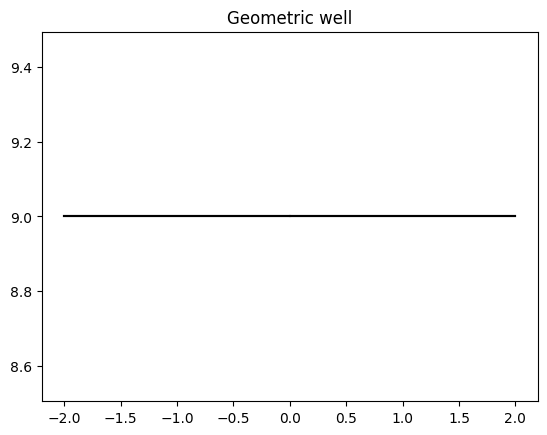

In [32]:
import warnings
# Well
@jit(nopython=True)
def well_z(r):  
    return (r >= 0)*w_h
@jit(nopython=True)
def well_r(z_pos):
    return r_out
r_span= np.linspace(0, l//2, 100)
z_span= np.linspace(0, w_h, 100)
plt.plot(r_span,well_z(r_span),color="black")
plt.plot(-r_span,well_z(r_span),color="black")
plt.plot([-l//2,l//2],[cap,cap],color="black")
plt.title("Geometric well")
#plt.plot(z_span,well_r(z_span))

Maximum dwell time at log10(t) = -0.8894618072532053


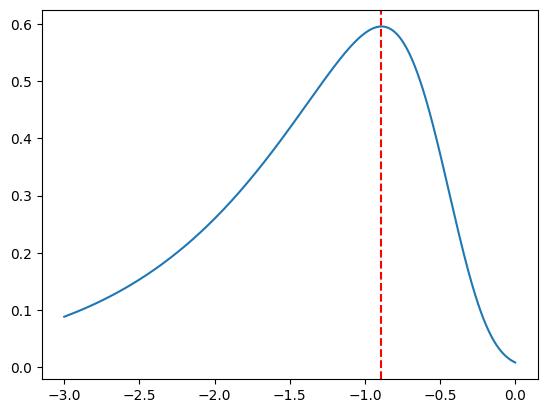

In [33]:
from scipy.special import jn_zeros
n=100
jn_zero = jn_zeros(0, n)
def dwell(t):
    return 4*np.sum(np.exp(-jn_zero[None,:]**2*t[:,None]),axis=1)
unit= r_out**2/D
t=np.linspace(0.001, 1, 10000)
x=np.log10(t)
y=dwell(t/unit)/unit*t*np.log(10)
x_max=x[np.argmax(y)]
print("Maximum dwell time at log10(t) =", x_max)
plt.plot(x,y , label="Dwell time")
plt.axvline(x_max, color='red', linestyle='--', label='Max dwell time')

In [26]:
dt = 1e-6
sigma = np.sqrt(2*D*dt)
print(sigma)

0.0014177446878757825


In [ ]:
#Averaged Wander
import numpy as np
from numba import jit
import time

np.random.seed(seed=0)

# Define the position arrays for analysis

# Fixed time step Monte Carlo simulation using Wiener process
@jit(nopython=True)
def shift(x):
    l = 2
    return (x + l) % (2 * l) - l

@jit(nopython=True)
def monte_carlo_wander(L_max=int(1/dt)):
    # Calculate standard deviation for Wiener process
    sigma = np.sqrt(2*D*dt+2*(D**2)*beta*m*(np.exp(-dt/(beta*D*m))-1))
    
    # Initialize
    np.random.seed(seed=0)
    
    # Define the initial state of the nanoparticle
    r = np.random.uniform(low=r_out - epsilon, high=r_out)
    theta = np.random.uniform(low=0.0, high=2*np.pi)
    z_min = well_z(r)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = np.random.uniform(low=z_min, high=cap)
    radius = np.sqrt(x**2 + y**2)
    t = 0.0
    
    # IN = 1, OUT = 0
    if radius <= r_out:
        prev_in_well = 1
    else:
        prev_in_well = 0
        
    dwell_track = np.zeros(L_max)
    x_frame, y_frame, z_frame, t_frame = [x, x], [y, y], [z, z], [t, t]
    Z = []
    enter_track = np.zeros((L_max, 2))
    leave_track = np.zeros((L_max, 2))
    
    i = 1
    L = 0
    
    while L < L_max - 1:
        # Store previous frame values
        x_frame, y_frame, z_frame, t_frame = [x_frame[-2], x_frame[-1]], [y_frame[-2], y_frame[-1]], [z_frame[-2], z_frame[-1]], [t_frame[-2], t_frame[-1]]
        
        # Simulate until we reach the next frame time
        while t < i / fps:
            # Generate random steps using Wiener process: dx = √(2DΔt) * N(0,1)
            dx = sigma * np.random.normal(0, 1)
            dy = sigma * np.random.normal(0, 1)
            dz = sigma * np.random.normal(0, 1)
            
            # Proposed new positions
            x = x + dx
            y = y + dy
            if ((z + dz) <= cap) and ((z + dz) >= w_h): 
                z = z + dz
            
            # Handle boundary conditions (reflective boundaries)
            # For x and y: periodic boundaries with period 4 (based on your shift function)
            x = (x + 2.0) % 4.0 - 2.0
            y = (y + 2.0) % 4.0 - 2.0
            

            # Update positions
            t += dt
            
            # Store trajectory
            x_frame.append(x)
            y_frame.append(y)
            z_frame.append(z)
            t_frame.append(t)
        
        # Interpolate to get frame values at exact frame times
        x_interp = ((x_frame[-1] * (i/fps - t_frame[-2]) + 
                    x_frame[-2] * (t_frame[-1] - i/fps)) / 
                   (t_frame[-1] - t_frame[-2]))
        y_interp = ((y_frame[-1] * (i/fps - t_frame[-2]) + 
                    y_frame[-2] * (t_frame[-1] - i/fps)) / 
                   (t_frame[-1] - t_frame[-2]))
        z_interp = ((z_frame[-1] * (i/fps - t_frame[-2]) + 
                    z_frame[-2] * (t_frame[-1] - i/fps)) / 
                   (t_frame[-1] - t_frame[-2]))
        
        x_frame.append(x_interp)
        y_frame.append(y_interp)
        z_frame.append(z_interp)
        t_frame.append(i/fps)
        
        # Swap last two elements for proper ordering
        x_frame[-2], x_frame[-1] = x_frame[-1], x_frame[-2]
        y_frame[-2], y_frame[-1] = y_frame[-1], y_frame[-2]
        z_frame[-2], z_frame[-1] = z_frame[-1], z_frame[-2]
        t_frame[-2], t_frame[-1] = t_frame[-1], t_frame[-2]
        
        # Calculate averages over the frame
        avg_x = np.trapz(x_frame[:-1], x=t_frame[:-1]) / (1/fps)
        avg_y = np.trapz(y_frame[:-1], x=t_frame[:-1]) / (1/fps)
        avg_z = np.trapz(z_frame[:-1], x=t_frame[:-1]) / (1/fps)
        
        # Apply periodic boundary condition for radius calculation
        radius = np.sqrt(((avg_x + 2.0) % (4.0) - 2.0)**2 + 
                        ((avg_y + 2.0) % (4.0) - 2.0)**2)
        Z.append(avg_z)
        
        # Track well entries and exits
        if radius <= r_out:
            if prev_in_well == 0:
                L += 1
                enter_track[L] = shift(np.array([avg_x, avg_y]))
            dwell_track[L] += 1/fps
            prev_in_well = 1
        else:
            if prev_in_well == 1:
                leave_track[L] = shift(np.array([avg_x, avg_y]))
                # Calculate angle difference (handling periodicity)
            prev_in_well = 0
        
        i += 1
    
    return dwell_track, Z

# Run the simulation
start_time = time.time()
dwell_track, z = monte_carlo_wander(L_max=int(1/dt))
end_time = time.time()
print(end_time - start_time)

In [34]:
#Non-averaged Wander
import numpy as np
import time
from numba import jit

np.random.seed(seed=0)

@jit(nopython=True)
def shift(x):
    l = 2
    return (x + l) % (2 * l) - l

@jit(nopython=True)
def MC_wander(L_max=10**5):
    
    sigma = np.sqrt(2*D*dt+2*(D**2)*beta*m*(np.exp(-dt/(beta*D*m))-1))
    
    # Initialize time
    t = 0.0

    # Define the initial state of the nanoparticle
    r = np.random.uniform(low=r_out - epsilon, high=r_out)
    theta = np.random.uniform(low=0.0, high=2*np.pi)
    z_min = well_z(r)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = np.random.uniform(low=z_min, high=cap)
    
    shifted_x = shift(np.array([x]))[0]
    shifted_y = shift(np.array([y]))[0]
    radius = np.sqrt(shifted_x**2 + shifted_y**2)
    
    # Initialize tracking arrays
    dwell_track = np.zeros(L_max)
    enter_track = np.zeros((L_max, 2))
    leave_track = np.zeros((L_max, 2))
    
    # IN = 1, OUT = 0
    if radius <= r_out:
        prev_in_well = 1
    else:
        prev_in_well = 0
    
    L = 0
    
    while L < L_max - 1:
        # Generate random steps using Wiener process
        dx = sigma * np.random.normal(0, 1)
        dy = sigma * np.random.normal(0, 1)
        dz = sigma * np.random.normal(0, 1)
        
        # Proposed new positions
        x = x + dx
        y = y + dy
        if ((z + dz) <= cap and (z + dz) >= w_h):
            z = z + dz
        
        # Get shifted coordinates for boundary checking
        shifted_x = shift(np.array([x]))[0]
        shifted_y = shift(np.array([y]))[0]
        
        
        # Update time
        t += dt
        radius = np.sqrt(shifted_x**2 + shifted_y**2)
        
        # Track well entries and exits
        if radius <= r_out:
            if prev_in_well == 0:
                L = L + 1
                enter_track[L] = np.array([shifted_x, shifted_y])
            dwell_track[L] += dt
            prev_in_well = 1
        else:
            if prev_in_well == 1:
                leave_track[L] = np.array([shifted_x, shifted_y])
            prev_in_well = 0
    return dwell_track, z

# Run the simulation
start_time = time.time()
dwell_track, z = MC_wander(L_max=10**6)
end_time = time.time()
print(end_time - start_time)

2983.806605577469


In [ ]:
#Non-averaged Restart
import numpy as np
import time
from numba import jit

np.random.seed(seed=0)

@jit(nopython=True)
def shift(x):
    l = 2
    return (x + l) % (2 * l) - l

@jit(nopython=True)
def MC_restart(L_max=10**5):
    
    sigma = np.sqrt(2*D*dt+2*(D**2)*beta*m*(np.exp(-dt/(beta*D*m))-1))
    
    # Initialize time
    t = 0.0

    # Define the initial state of the nanoparticle
    r = np.random.uniform(low=r_out - epsilon, high=r_out)
    theta = np.random.uniform(low=0.0, high=2*np.pi)
    z_min = well_z(r)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = np.random.uniform(low=z_min, high=cap)
    
    shifted_x = shift(np.array([x]))[0]
    shifted_y = shift(np.array([y]))[0]
    radius = np.sqrt(shifted_x**2 + shifted_y**2)
    
    # Initialize tracking arrays
    dwell_track = np.zeros(L_max)
    enter_track = np.zeros((L_max, 2))
    leave_track = np.zeros((L_max, 2))
    
    # IN = 1, OUT = 0
    if radius <= r_out:
        prev_in_well = 1
    else:
        prev_in_well = 0
    
    L = 0
    
    while L < L_max - 1:
        # Generate random steps using Wiener process
        dx = sigma * np.random.normal(0, 1)
        dy = sigma * np.random.normal(0, 1)
        dz = sigma * np.random.normal(0, 1)
        
        # Proposed new positions
        x = x + dx
        y = y + dy
        if ((z + dz) <= cap and (z + dz) >= w_h):
            z = z + dz
        
        # Get shifted coordinates for boundary checking
        shifted_x = shift(np.array([x]))[0]
        shifted_y = shift(np.array([y]))[0]
        
        
        # Update time
        t += dt
        radius = np.sqrt(shifted_x**2 + shifted_y**2)
        
        # Track well entries and exits
        if radius <= r_out:
            if prev_in_well == 0:
                L = L + 1
                enter_track[L] = np.array([shifted_x, shifted_y])
            dwell_track[L] += dt
            prev_in_well = 1
        else:
            if prev_in_well == 1:
                leave_track[L] = np.array([shifted_x, shifted_y])
            prev_in_well = 0
            r = np.random.uniform(low=r_out - epsilon, high=r_out)
            theta = np.random.uniform(low=0.0, high=2*np.pi)
            z_min = well_z(r)
            x = r * np.cos(theta)
            y = r * np.sin(theta)
            z = np.random.uniform(low=z_min, high=cap)
    return dwell_track, z

# Run the simulation
start_time = time.time()
dwell_track, z = MC_restart(L_max=10**4)
end_time = time.time()
print(end_time - start_time)

In [28]:
import numpy as np
import time
from numba import jit

np.random.seed(seed=0)

@jit(nopython=True)
def shift(x):
    l = 2
    return (x + l) % (2 * l) - l

@jit(nopython=True)
def MC_wander(L_max=10**6):
    
    sigma = np.sqrt(2*D*dt)
    
    # Initialize time
    t = 0.0

    # Define the initial state of the nanoparticle
    r = np.random.uniform(low=r_out - epsilon, high=r_out)
    theta = np.random.uniform(low=0.0, high=2*np.pi)
    z_min = well_z(r)
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    z = np.random.uniform(low=z_min, high=cap)
    
    shifted_x = shift(np.array([x]))[0]
    shifted_y = shift(np.array([y]))[0]
    radius = np.sqrt(shifted_x**2 + shifted_y**2)
    
    # Initialize tracking arrays
    dwell_track = np.zeros(L_max)
    radius_track = np.zeros(L_max)  # This will now store initial entry radius
    enter_track = np.zeros((L_max, 2))
    leave_track = np.zeros((L_max, 2))
    
    # IN = 1, OUT = 0
    if radius <= r_out:
        prev_in_well = 1
    else:
        prev_in_well = 0
    
    L = 0
    
    while L < L_max - 1:
        # Generate random steps using Wiener process
        dx = sigma * np.random.normal(0, 1)
        dy = sigma * np.random.normal(0, 1)
        dz = sigma * np.random.normal(0, 1)
        
        # Proposed new positions
        x = x + dx
        y = y + dy
        if ((z + dz) <= cap and (z + dz) >= w_h):
            z = z + dz
        
        # Get shifted coordinates for boundary checking
        shifted_x = shift(np.array([x]))[0]
        shifted_y = shift(np.array([y]))[0]
        
        # Update time
        t += dt
        radius = np.sqrt(shifted_x**2 + shifted_y**2)
        
        # Track well entries and exits
        if radius <= r_out:
            if prev_in_well == 0:
                # ENTERING THE WELL - store the initial radius at entry
                L = L + 1
                radius_track[L] = radius  # Store the radius at the moment of entry
                enter_track[L] = np.array([shifted_x, shifted_y])
            dwell_track[L] += dt
            prev_in_well = 1
        else:
            if prev_in_well == 1:
                leave_track[L] = np.array([shifted_x, shifted_y])
            prev_in_well = 0
    return dwell_track, radius_track, z

# Run the simulation
start_time = time.time()
dwell_track, radius_track, z = MC_wander(L_max=10**6)
end_time = time.time()
print(end_time - start_time)

KeyboardInterrupt: 

In [1]:
import numpy as np
import pandas as pd
from openpyxl import load_workbook
import xlsxwriter

In [36]:
with pd.ExcelWriter(path, engine='openpyxl') as writer:
	d = {'dwell_time': dwell_track[1:-1]}
	df = pd.DataFrame(data = d)
	df.to_excel(writer, index = True, sheet_name = 'dwell time')

In [35]:
with xlsxwriter.Workbook(path) as workbook:
    worksheet = workbook.add_worksheet()
    
    # Write header at B1 (row 0, column 1)
    worksheet.write(0, 1, 'radius')  # (row, column, value)
    
    # Write array data starting at B2 (row 1, column 1)
    worksheet.write_column(1, 1, radius_track)  # (start_row, start_col, data)

NameError: name 'radius_track' is not defined

In [38]:
path1 = './Excel/1.005_depth=0dt=1e-07_angle_wander_MonteCarlo.xlsx'
data1 = pd.read_excel(path1, sheet_name='dwell time')
path2 = './Excel/1.005_depth=0dt=1e-06_angle_wander_MonteCarlo.xlsx'
data2 = pd.read_excel(path2, sheet_name='dwell time')
path3 = './Excel/1.005_depth=0dt=1e-05_angle_wander_MonteCarlo.xlsx'
data3 = pd.read_excel(path3, sheet_name='dwell time')
path4 = './Excel/1.005_depth=0dt=0.0001_angle_wander_MonteCarlo.xlsx'
data4 = pd.read_excel(path4, sheet_name='dwell time')
path5 = './Excel/1.005_depth=0dt=0.001_angle_wander_MonteCarlo.xlsx'
data5 = pd.read_excel(path5, sheet_name='dwell time')

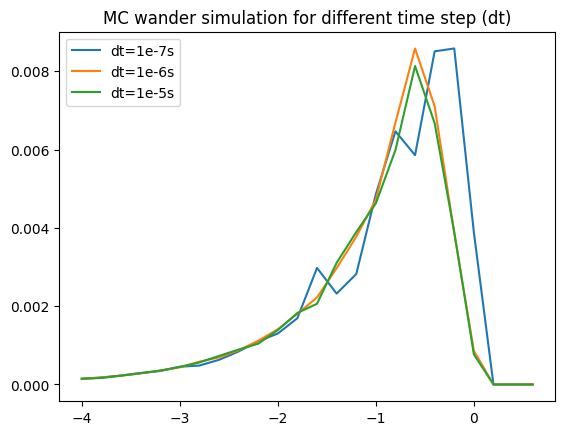

In [39]:
plt.title('MC wander simulation for different time step (dt)')
bin_edge1=np.arange(-4.1,0.9,0.2)
bin_center1 = (bin_edge1[:-1] + bin_edge1[1:]) / 2
bin_widths_linear1 = - 10**(-bin_edge1[:-1]) + 10**(-(bin_edge1[:-1] - 0.2))
Time=data1['dwell_time']
hist1,bin1= np.histogram(np.log10(Time), bins = bin_edge1,density=True)
plt.plot(bin_center1,hist1/bin_widths_linear1,label='dt=1e-7s')
bin_edge2=np.arange(-4.1,0.9,0.2)
bin_center2 = (bin_edge2[:-1] + bin_edge2[1:]) / 2
bin_widths_linear2 = - 10**(-bin_edge2[:-1]) + 10**(-(bin_edge2[:-1] - 0.2))
Time=data2['dwell_time']
hist2,bin2= np.histogram(np.log10(Time), bins = bin_edge2,density=True)
plt.plot(bin_center2,hist2/bin_widths_linear2,label='dt=1e-6s')
bin_edge3=np.arange(-4.1,0.9,0.2)
bin_center3 = (bin_edge3[:-1] + bin_edge3[1:]) / 2
bin_widths_linear3 = - 10**(-bin_edge3[:-1]) + 10**(-(bin_edge3[:-1] - 0.2))
Time=data3['dwell_time']
hist3,bin3= np.histogram(np.log10(Time), bins = bin_edge3,density=True)
plt.plot(bin_center3,hist3/bin_widths_linear3,label='dt=1e-5s')
'''
bin_edge4=np.arange(-2.1,0.9,0.2)
bin_center4 = (bin_edge4[:-1] + bin_edge4[1:]) / 2
Time=data4['dwell_time']
hist4,bin4= np.histogram(np.log10(Time), bins = bin_edge4,density=True)
plt.plot(bin_center4,hist4,label='dt=1e-4s')
bin_edge5=np.arange(-2.1,0.9,0.2)
bin_center5 = (bin_edge5[:-1] + bin_edge5[1:]) / 2
Time=data5['dwell_time']
hist5,bin5= np.histogram(np.log10(Time), bins = bin_edge5,density=True)
plt.plot(bin_center5,hist5,label='dt=1e-3s')
'''
plt.legend()

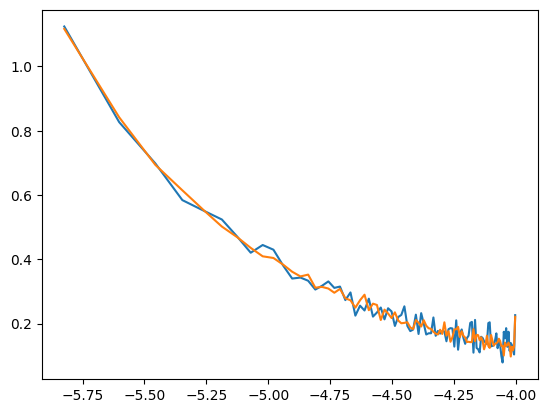

In [71]:
Time=data1['dwell_time']
bin_edge1=np.arange(1/1000000,1/10000,1/1000000)
bin_center1 = (bin_edge1[:-1] + bin_edge1[1:]) / 2
accuracy=10
hist1,bin1= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge1,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center1),bin_center1*np.log(10)*hist1)
Time=data2['dwell_time']
bin_edge2=np.arange(1/1000000,1/10000,1/1000000)
bin_center2 = (bin_edge2[:-1] + bin_edge2[1:]) / 2
accuracy=10
hist2,bin2= np.histogram(np.round(Time,decimals=accuracy), bins = np.round(bin_edge2,decimals=accuracy), density = True)
plt.plot(np.log10(bin_center2),bin_center2*np.log(10)*hist2)

In [9]:
path1 = './Excel/1.005_depth=0dt=0.0001_angle_restart_epsilon=0.9_MonteCarlo.xlsx'
data1 = pd.read_excel(path1, sheet_name='dwell time')
path2 = './Excel/1.005_depth=0dt=1e-05_angle_restart_epsilon=0.9_MonteCarlo.xlsx'
data2 = pd.read_excel(path2, sheet_name='dwell time')

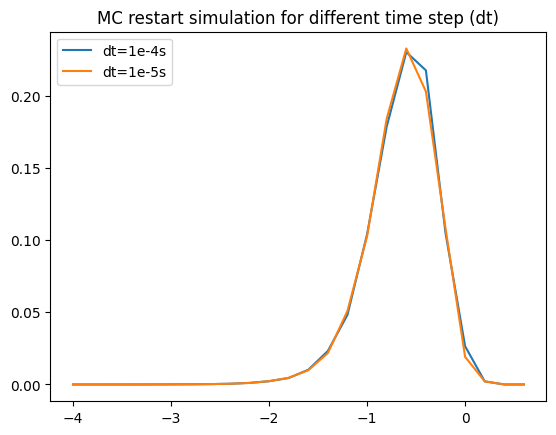

In [11]:
plt.title('MC restart simulation for different time step (dt)')
bin_edge1=np.arange(-4.1,0.9,0.2)
bin_center1 = (bin_edge1[:-1] + bin_edge1[1:]) / 2
bin_widths_linear1 = - 10**(-bin_edge1[:-1]) + 10**(-(bin_edge1[:-1] - 0.2))
Time=data1['dwell_time']
hist1,bin1= np.histogram(np.log10(Time), bins = bin_edge1,density=True)
plt.plot(bin_center1,hist1/bin_widths_linear1,label='dt=1e-4s')
bin_edge2=np.arange(-4.1,0.9,0.2)
bin_center2 = (bin_edge2[:-1] + bin_edge2[1:]) / 2
bin_widths_linear2 = - 10**(-bin_edge2[:-1]) + 10**(-(bin_edge2[:-1] - 0.2))
Time=data2['dwell_time']
hist2,bin2= np.histogram(np.log10(Time), bins = bin_edge2,density=True)
plt.plot(bin_center2,hist2/bin_widths_linear2,label='dt=1e-5s')
plt.legend()

In [13]:
path1 = './Excel/1.005_depth=0dt=0.0001_angle_restart_epsilon=0.9_MonteCarlo.xlsx'
data1 = pd.read_excel(path1, sheet_name='dwell time')
path2 = './Excel/1.005_depth=0dt=0.0001_angle_restart_epsilon=0.5_MonteCarlo.xlsx'
data2 = pd.read_excel(path2, sheet_name='dwell time')
path3 = './Excel/1.005_depth=0dt=0.0001_angle_restart_epsilon=0.1_MonteCarlo.xlsx'
data3 = pd.read_excel(path3, sheet_name='dwell time')

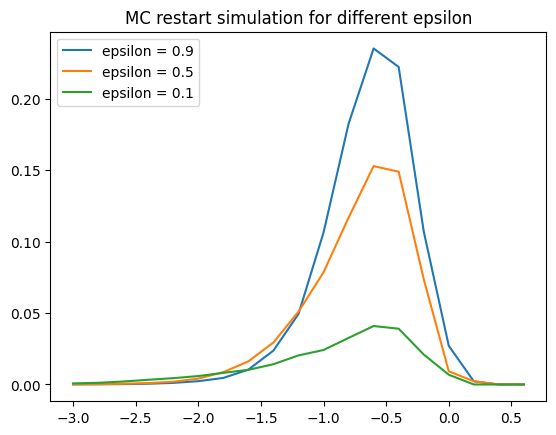

In [14]:
plt.title('MC restart simulation for different epsilon')
bin_edge1=np.arange(-3.1,0.9,0.2)
bin_center1 = (bin_edge1[:-1] + bin_edge1[1:]) / 2
bin_widths_linear1 = - 10**(-bin_edge1[:-1]) + 10**(-(bin_edge1[:-1] - 0.2))
Time=data1['dwell_time']
hist1,bin1= np.histogram(np.log10(Time), bins = bin_edge1,density=True)
plt.plot(bin_center1,hist1/bin_widths_linear1,label='epsilon = 0.9')
bin_edge2=np.arange(-3.1,0.9,0.2)
bin_center2 = (bin_edge2[:-1] + bin_edge2[1:]) / 2
bin_widths_linear2 = - 10**(-bin_edge2[:-1]) + 10**(-(bin_edge2[:-1] - 0.2))
Time=data2['dwell_time']
hist2,bin2= np.histogram(np.log10(Time), bins = bin_edge2,density=True)
plt.plot(bin_center2,hist2/bin_widths_linear2,label='epsilon = 0.5')
bin_edge3=np.arange(-3.1,0.9,0.2)
bin_center3 = (bin_edge3[:-1] + bin_edge3[1:]) / 2
bin_widths_linear3 = - 10**(-bin_edge3[:-1]) + 10**(-(bin_edge3[:-1] - 0.2))
Time=data3['dwell_time']
hist3,bin3= np.histogram(np.log10(Time), bins = bin_edge3,density=True)
plt.plot(bin_center3,hist3/bin_widths_linear3,label='epsilon = 0.1')
plt.legend()

In [44]:
path0 = './Excel/1.005_depth=0dt=1e-06_initial_position_MonteCarlo.xlsx'
data0 = pd.read_excel(path0, sheet_name='Sheet1')
path1= './Excel/1.005_depth=0dt=1e-05_initial_position_MonteCarlo.xlsx'
data1 = pd.read_excel(path1, sheet_name='Sheet1')
path2= './Excel/1.005_depth=0dt=0.0001_initial_position_MonteCarlo.xlsx'
data2 = pd.read_excel(path2, sheet_name='Sheet1')
path3= './Excel/1.005_depth=0dt=0.001_initial_position_MonteCarlo.xlsx'
data3 = pd.read_excel(path3, sheet_name='Sheet1')
path4= './Excel/1.005_depth=0dt=0.01_initial_position_MonteCarlo.xlsx'
data4 = pd.read_excel(path4, sheet_name='Sheet1')

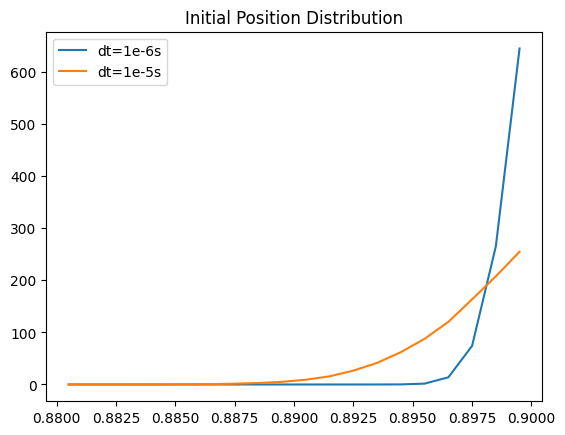

In [ ]:
plt.title('Initial Position Distribution')
bin_edge0=np.arange(0.88,0.9,0.001)
bin_center0 = (bin_edge0[:-1] + bin_edge0[1:]) / 2
radius=data0['radius']
hist0,bin0= np.histogram(radius, bins = bin_edge0,density=True)
plt.plot(bin_center0,hist0, label='dt=1e-6s')
radius=data1['radius']
hist1,bin1= np.histogram(radius, bins = bin_edge0,density=True)
plt.plot(bin_center0,hist1, label='dt=1e-5s')
radius=data2['radius']
'''
hist2,bin2= np.histogram(radius, bins = bin_edge0,density=True)
plt.plot(bin_center0,hist2, label='dt=1e-4s')
radius=data3['radius']
hist3,bin3= np.histogram(radius, bins = bin_edge0,density=True)
plt.plot(bin_center0,hist3, label='dt=1e-3s')
radius=data4['radius']
hist4,bin4= np.histogram(radius, bins = bin_edge0,density=True)
plt.plot(bin_center0,hist4, label='dt=1e-2s')
'''
plt.legend()